In [ ]:
import torch 
import torch.nn as nn
import numpy as np 
from datasets import load_dataset
from tqdm import tqdm 
import yaml 
from pathlib import Path

from IPython.display import Audio
import importlib

import torchaudio 

from typing import Dict, List

import robustness.audio_functions.audio_transforms as at 

from lightning_scripts.utils.model_build_utils import get_model
from lightning_scripts.byola_lightning_module import BYOLAModule

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)
from pathlib import Path

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/common.py:31: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


In [17]:
torch.cuda.empty_cache()

# Get models

In [4]:
# SSL models with different lambda values
ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01.yaml")
ssl_lambda_1_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01.yaml")
ssl_lambda_2_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01.yaml")
ssl_lambda_3_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01.yaml")
ssl_lambda_4_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01.yaml")
ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01.yaml")

# Scaled SSL models
ssl_scaled_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_scaled_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")

# Supervised models
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

# BYOL-A config
byola_config = "byol-a/config.yaml"
byola_config = yaml.load(open(byola_config, 'r'), Loader=yaml.FullLoader)
# Load models
models = {}
model_name_map = {}  # Maps internal name to standardized name


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# SSL models
models["ssl_λ=0.0"] = get_model(ssl_lambda_0_config, layer_out="relu4")
model_name_map["ssl_λ=0.0"] = "CochDNN9 ssl λ=0.0"

models["ssl_λ=0.1"] = get_model(ssl_lambda_1_config, layer_out="relu4")
model_name_map["ssl_λ=0.1"] = "CochDNN9 ssl λ=0.1"

models["ssl_λ=0.2"] = get_model(ssl_lambda_2_config, layer_out="relu4")
model_name_map["ssl_λ=0.2"] = "CochDNN9 ssl λ=0.2"

models["ssl_λ=0.3"] = get_model(ssl_lambda_3_config, layer_out="relu4")
model_name_map["ssl_λ=0.3"] = "CochDNN9 ssl λ=0.3"

models["ssl_λ=0.4"] = get_model(ssl_lambda_4_config, layer_out="relu4")
model_name_map["ssl_λ=0.4"] = "CochDNN9 ssl λ=0.4"

models["ssl_λ=0.5"] = get_model(ssl_lambda_5_config, layer_out="relu4")
model_name_map["ssl_λ=0.5"] = "CochDNN9 ssl λ=0.5"

# Scaled SSL models
models["scaled_ssl_λ=0.0"] = get_model(ssl_scaled_lambda_0_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.0"] = "CochDNN9 scaled ssl λ=0.0"

models["scaled_ssl_λ=0.5"] = get_model(ssl_scaled_lambda_5_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.5"] = "CochDNN9 scaled ssl λ=0.5"

# Supervised models
models["word"] = get_model(word_config, supervised=True, layer_out="relu4")
model_name_map["word"] = "CochDNN9 supervised word"

models["audioset"] = get_model(audioset_config, supervised=True, layer_out="relu4")
model_name_map["audioset"] = "CochDNN9 supervised audioset"

models["multitask"] = get_model(multitask_config, supervised=True, layer_out="relu4")
model_name_map["multitask"] = "CochDNN9 supervised multi-task"

models["unbal_audioset"] = get_model(unbal_audioset_config, supervised=True, layer_out="relu4")
model_name_map["unbal_audioset"] = "CochDNN9 scaled supervised"

models["byol-a"] = BYOLAModule(byola_config).cuda().eval()
model_name_map["byol-a"] = "byol-a"

# push all models to device
for model in models.values():
    model.to(DEVICE)


/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weight_file, map_l

# Get the dataset 

In [5]:
speech_commands = load_dataset("google/speech_commands", 'v0.01')

README.md: 0.00B [00:00, ?B/s]

speech_commands.py: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/51093 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6799 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3081 [00:00<?, ? examples/s]

In [6]:
train_split = speech_commands['train']
# remove silence 
train_split = train_split.filter(lambda example: (not ('_silence_' in example['file'])) and (not (example['audio']['array'] is None)))
train_split = train_split.shuffle(seed=1)
val_split = speech_commands['validation']
test_split = speech_commands['test']

Filter:   0%|          | 0/51093 [00:00<?, ? examples/s]

In [7]:
class TripletDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for creating triplets from speech_commands dataset.
    
    Level discrimination task:
    - Each clip contains two words with different levels (a and b, either higher or lower)
    - Anchor: word1_A + word2_A with level relationship (word1 higher/lower than word2)
    - Positive: word1_B + word2_B with same level relationship as anchor (different words)
    - Negative: word1_C + word2_C with reversed level relationship (different words)
    
    All words are different across anchor, positive, and negative.
    """
    
    def __init__(self, dataset_split, seed=None, num_triplets=500, target_sr=20000, sig_length=40000):
        """
        Args:
            dataset_split: HuggingFace dataset split (train/val/test)
            seed: Random seed for reproducibility
            num_triplets: Number of triplets to generate
            target_sr: Target sample rate
            sig_length: Target signal length in samples
        """
        self.dataset_split = dataset_split
        self.target_sr = target_sr
        self.sample_rate = target_sr
        self.sig_length = sig_length
        
        # Get unique labels
        self.label_list = sorted(list(set([ex['label'] for ex in dataset_split])))
        
        # Group examples by label
        self.examples_by_label = {}
        for idx, example in enumerate(dataset_split):
            label = example['label']
            if label not in self.examples_by_label:
                self.examples_by_label[label] = []
            self.examples_by_label[label].append(idx)
        
        # Filter out labels with fewer than 2 examples
        self.valid_labels = {label: indices for label, indices in self.examples_by_label.items() 
                            if len(indices) >= 2}
        
        # Pre-generate triplets for deterministic length
        # Talker selection will be done deterministically in __getitem__ using idx as seed
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
        
        self.triplets = []
        for _ in range(num_triplets):
            # Randomly select two words
            word1, word2 = np.random.choice(self.label_list, size=2, replace=True)
            # Randomly decide which word has higher level (True = word1 higher, False = word2 higher)
            word1_higher = np.random.choice([True, False])
            self.triplets.append((word1, word2, word1_higher))
    
    def __len__(self):
        return len(self.triplets)
    
    def _select_unique_indices(self, word1, word2, rng, num_sets=3):
        """
        Select unique talker indices for anchor, positive, and negative.
        Ensures all indices are unique across all three sets.
        """
        indices1 = self.examples_by_label.get(word1, [])
        indices2 = self.examples_by_label.get(word2, [])
        
        if len(indices1) < num_sets or len(indices2) < num_sets:
            # Fallback: allow reuse if not enough examples
            selected1 = rng.choice(indices1, size=num_sets, replace=True)
            selected2 = rng.choice(indices2, size=num_sets, replace=True)
        else:
            selected1 = rng.choice(indices1, size=num_sets, replace=False)
            selected2 = rng.choice(indices2, size=num_sets, replace=False)
        
        # Ensure we return arrays even for num_sets=1
        if num_sets == 1:
            selected1 = np.array([selected1]) if not isinstance(selected1, np.ndarray) else selected1
            selected2 = np.array([selected2]) if not isinstance(selected2, np.ndarray) else selected2
        return selected1, selected2
    
    def _load_and_normalize_words(self, word, idx, rng):
        """Load and normalize a single word audio."""
        example = self.dataset_split[idx]
        audio = torch.from_numpy(example['audio']['array']).float()
        sr = example['audio']['sampling_rate']
        
        # Resample if needed
        if sr != self.target_sr:
            audio = torchaudio.functional.resample(audio.unsqueeze(0), sr, self.target_sr).squeeze(0)
        
        # RMS normalize
        rms = torch.sqrt(torch.mean(audio ** 2))
        if rms > 1e-6:
            audio = audio / rms
        
        return audio
    
    def _create_word_sequence(self, word1, word2, word1_idx, word2_idx, word1_higher, rng):
        """Create a sequence of two words with level difference."""
        audio1 = self._load_and_normalize_words(word1, word1_idx, rng)
        audio2 = self._load_and_normalize_words(word2, word2_idx, rng)
        
        # Apply level difference: scale one word relative to the other
        level_ratio = 0.20  # Lower word is 70% of higher word's level
        if word1_higher:
            audio2 = audio2 * level_ratio
        else:
            audio1 = audio1 * level_ratio
        
        # Concatenate words
        sequence = torch.cat([audio1, audio2])
        
        # Center crop or pad to target length
        if len(sequence) < self.sig_length:
            pad_dur = (self.sig_length - len(sequence)) // 2 + 1
            sequence = nn.functional.pad(sequence, (pad_dur, pad_dur), "constant", 0)
        
        start_idx = int((len(sequence) - self.sig_length) / 2)
        sequence = sequence[start_idx:start_idx + self.sig_length]
        
        return sequence
    
    def __getitem__(self, idx):
        """
        Returns a tuple: (clips, sr, triplet_info)
        - clips: dict with 'anchor', 'positive', 'negative' keys containing audio tensors
        - sr: sample rate (scalar)
        - triplet_info: dict with metadata about the triplet
        """
        word1, word2, word1_higher = self.triplets[idx]
        rng = np.random.RandomState(idx)
        
        # Select 6 unique words (2 for anchor, 2 for positive, 2 for negative)
        available_words = [w for w in self.label_list if w != word1 and w != word2]
        if len(available_words) < 4:
            available_words = self.label_list
        
        # Anchor words
        word1_A, word2_A = word1, word2
        
        # Positive words (different from anchor words)
        word1_B, word2_B = rng.choice(available_words, size=2, replace=False)
        used_words_AB = {word1_A, word2_A, word1_B, word2_B}
        while word1_B in used_words_AB or word2_B in used_words_AB or word1_B == word2_B:
            word1_B, word2_B = rng.choice(available_words, size=2, replace=False)
        
        # Negative words (different from all previous words)
        remaining_words = [w for w in available_words if w not in used_words_AB]
        if len(remaining_words) < 2:
            remaining_words = [w for w in self.label_list if w not in used_words_AB]
        if len(remaining_words) < 2:
            remaining_words = self.label_list
        
        word1_C, word2_C = rng.choice(remaining_words, size=2, replace=False)
        used_words_ABC = used_words_AB.union({word1_C, word2_C})
        while word1_C in used_words_ABC or word2_C in used_words_ABC or word1_C == word2_C:
            word1_C, word2_C = rng.choice(remaining_words, size=2, replace=False)
        
        # Select unique indices for each word pair
        selected1_A, selected2_A = self._select_unique_indices(word1_A, word2_A, rng, num_sets=1)
        word1_idx_A, word2_idx_A = int(selected1_A[0]), int(selected2_A[0])
        selected1_B, selected2_B = self._select_unique_indices(word1_B, word2_B, rng, num_sets=1)
        word1_idx_B, word2_idx_B = int(selected1_B[0]), int(selected2_B[0])
        selected1_C, selected2_C = self._select_unique_indices(word1_C, word2_C, rng, num_sets=1)
        word1_idx_C, word2_idx_C = int(selected1_C[0]), int(selected2_C[0])
        
        # Create anchor: word1_A + word2_A with level relationship
        anchor = self._create_word_sequence(word1_A, word2_A, word1_idx_A, word2_idx_A, word1_higher, rng)
        
        # Create positive: word1_B + word2_B with same level relationship
        positive = self._create_word_sequence(word1_B, word2_B, word1_idx_B, word2_idx_B, word1_higher, rng)
        
        # Create negative: word1_C + word2_C with reversed level relationship
        negative = self._create_word_sequence(word1_C, word2_C, word1_idx_C, word2_idx_C, not word1_higher, rng)
        
        clips = {
            "anchor": anchor,
            "positive": positive,
            "negative": negative
        }
        
        triplet_info = {
            "anchor": {
                "word1": word1_A,
                "word2": word2_A,
                "word1_higher": word1_higher
            },
            "positive": {
                "word1": word1_B,
                "word2": word2_B,
                "word1_higher": word1_higher
            },
            "negative": {
                "word1": word1_C,
                "word2": word2_C,
                "word1_higher": not word1_higher
            }
        }
        
        return clips, self.target_sr, triplet_info


# Create dataset
triplet_dataset = TripletDataset(val_split, seed=0, num_triplets=2000)


In [8]:
def speech_commands_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

triplet_loader = torch.utils.data.DataLoader(
    triplet_dataset, batch_size=1, shuffle=False, collate_fn=speech_commands_triplet_collate
)
print(f"Triplet dataset ready: {len(triplet_dataset)} examples at target_sr={triplet_dataset.sample_rate}")

# Test the dataset format
clips, sr, triplet_info = triplet_dataset[0]
print(f"Sample rate: {sr}")
print(f"Clip shapes: anchor={clips['anchor'].shape}, positive={clips['positive'].shape}, negative={clips['negative'].shape}")
print(f"Triplet info: word1={triplet_info['anchor']['word1']}, word2={triplet_info['anchor']['word2']}")
print(f"Level relationship: anchor word1_higher={triplet_info['anchor']['word1_higher']}")
display(Audio(clips['anchor'], rate=sr))
display(Audio(clips['positive'], rate=sr))
display(Audio(clips['negative'], rate=sr))

Triplet dataset ready: 2000 examples at target_sr=20000
Sample rate: 20000
Clip shapes: anchor=torch.Size([40000]), positive=torch.Size([40000]), negative=torch.Size([40000])
Triplet info: word1=12, word2=15
Level relationship: anchor word1_higher=False


## Evaluation

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    """Encode audio batch to embeddings."""
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z


MODEL_SR = 20000
def distance_metrics_on_triplet(model, clips: Dict[str, torch.Tensor], sr: int) -> Dict[str, float]:
    """Compute embedding-space distance metrics for (anchor, positive, negative)."""
    waves: Dict[str, torch.Tensor] = {}
    for k, v in clips.items():
        w = v
        # BYOL-A wrapper handles its own resampling; this notebook provides 20kHz by default
        if isinstance(model, BYOLAModule):
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, 16_000).squeeze(0)
        elif sr != MODEL_SR:
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, MODEL_SR).squeeze(0)
        waves[k] = w.to(DEVICE)

    # Encode each example separately -- do not pair batch
    if isinstance(model, BYOLAModule):
        anchor_batch = waves["anchor"].unsqueeze(0)
        positive_batch = waves["positive"].unsqueeze(0)
        negative_batch = waves["negative"].unsqueeze(0)
    else:
        # robustness / cochdnn models expect [B, C, T]
        anchor_batch = waves["anchor"].unsqueeze(0).unsqueeze(1)
        positive_batch = waves["positive"].unsqueeze(0).unsqueeze(1)
        negative_batch = waves["negative"].unsqueeze(0).unsqueeze(1)

    z_anchor = encode_audio(model, anchor_batch)
    z_pos = encode_audio(model, positive_batch)
    z_neg = encode_audio(model, negative_batch)

    # L2
    pos_l2 = torch.norm(z_anchor - z_pos, p=2).item()
    neg_l2 = torch.norm(z_anchor - z_neg, p=2).item()

    # Squared L2
    pos_l2_sq = pos_l2**2
    neg_l2_sq = neg_l2**2

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "pos_l2_sq": pos_l2_sq,
        "neg_l2_sq": neg_l2_sq,
        "l2_judgement": int(pos_l2 < neg_l2),
        "sqr_l2_judgement": int(pos_l2_sq < neg_l2_sq),
    }


class CenterCropOrPad:
    def __init__(self, sig_length):
        self.sig_length = sig_length

    def __call__(self, x):
        if x.shape[0] < self.sig_length:
        # edge pad if x is too short 
            pad_dur = (self.sig_length - len(x)) // 2 + 1 
            # print(f"X shape before pad: {x.shape}")
            x = nn.functional.pad(x, (pad_dur, pad_dur), "constant", 0 )
            # print(f"X shape after pad: {x.shape}")
        # re-compute crop bound

        # else:        
        start_idx = int((x.shape[0] - self.sig_length)/2)
        x = x[start_idx:start_idx+self.sig_length]

        return x

crop_or_pad = CenterCropOrPad(40000)
db_spl = 60 
set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(db_spl)



In [11]:
# Evaluate models on triplets and collect simple L2 stats
all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(triplet_loader), total=len(triplet_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        word1 = triplet["anchor"]["word1"]
        word2 = triplet["anchor"]["word2"]
        word1_higher = triplet["anchor"]["word1_higher"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({
            "model": name,
            "batch_idx": batch_idx,
            "word1": word1,
            "word2": word2,
            "word1_higher": word1_higher
        })
        all_results.append(metrics)

results_df = pd.DataFrame(all_results)
display(results_df.head())


Evaluating triplets:   0%|          | 0/2000 [00:00<?, ?it/s]

,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,model,batch_idx,word1,word2,word1_higher
0,39.661469,38.773632,1573.032084,1503.394542,0,0,ssl_λ=0.0,0,12,15,False
1,37.055473,41.706757,1373.108104,1739.453545,1,1,ssl_λ=0.1,0,12,15,False
2,36.225403,46.043205,1312.279810,2119.976751,1,1,ssl_λ=0.2,0,12,15,False
3,31.986141,43.614529,1023.113229,1902.227110,1,1,ssl_λ=0.3,0,12,15,False
4,35.052288,52.210796,1228.662898,2725.967256,1,1,ssl_λ=0.4,0,12,15,False


In [21]:
model_name_map

{'ssl_λ=0.0': 'CochDNN9 ssl λ=0.0',
 'ssl_λ=0.1': 'CochDNN9 ssl λ=0.1',
 'ssl_λ=0.2': 'CochDNN9 ssl λ=0.2',
 'ssl_λ=0.3': 'CochDNN9 ssl λ=0.3',
 'ssl_λ=0.4': 'CochDNN9 ssl λ=0.4',
 'ssl_λ=0.5': 'CochDNN9 ssl λ=0.5',
 'scaled_ssl_λ=0.0': 'CochDNN9 scaled ssl λ=0.0',
 'scaled_ssl_λ=0.5': 'CochDNN9 scaled ssl λ=0.5',
 'word': 'CochDNN9 supervised word',
 'audioset': 'CochDNN9 supervised audioset',
 'multitask': 'CochDNN9 supervised multi-task',
 'unbal_audioset': 'CochDNN9 scaled supervised',
 'byol-a': 'byol-a'}

In [22]:
results_df['model_name'] = results_df['model'].map(model_name_map)

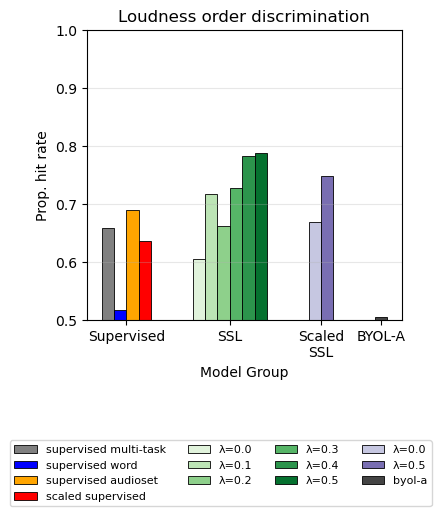

In [23]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='sqr_l2_judgement',
    title='Loudness order discrimination',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

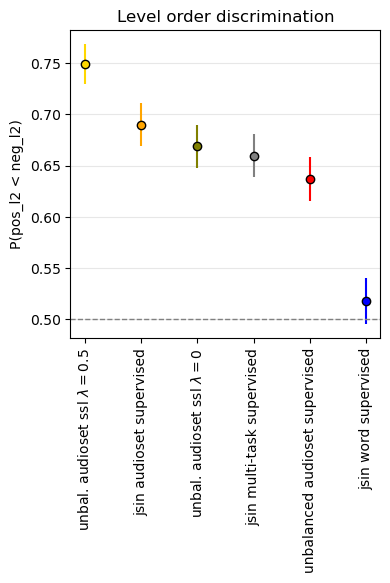

In [44]:
import matplotlib.pyplot as plt

judgement_rate = results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values( ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = results_df[results_df.model == model]["judgement_pos_lt_neg"].mean()
    error = 2 * results_df[results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(results_df[results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
# axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Level order discrimination")
axes.grid(True, axis="y", alpha=0.3)
plt.show()